# 02 - Feature Engineering

This notebook covers feature engineering and data preparation:
1. Engineering of features from the Vickers dataset
2. Engineering of pacing features
3. Preparing train/test split

**Inputs:** 
Cleaned Vickers data from `01_data_exploration`

**Outputs:** 
`data/processed/vickers_features.parquet`, `data/processed/train.parquet`, `data/processed/test.parquet`

## Setup

In [113]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

from src.data_loading import load_useable_vickers
from src.baselines import riegel_predict, vdot_from_race, vdot_predict

sns.set_theme(style='whitegrid')
%matplotlib inline

Load in out pruned Vickers dataset with only runners who submitted two races

In [114]:
df = load_useable_vickers()

---
## Part 0: Baseline Predictions 

Run Riegel and VDOT on every Vickers runner with a half marathon time, predict their marathon time, and compute error metrics. These metrics will be used to benchmarks my ML model.

### Filter to runners with both half marathon and marathon times

Load useable vickers gives us the useable data from the first notebook. This data only has runners who completed a marathon and also submitted two other races.

### Function to create full predictions

In [115]:
df['riegel_predicted'] = np.nan
df['vdot_predicted'] = np.nan


# selection here impacts error. order prioritizes races in distance decending for that reason.
fallback_order = [
    ('mh_ti_adj', 13.1),
    ('m10_ti_adj', 10),
    ('k10_ti_adj', 6.2),
    ('m5_ti_adj', 5),
    ('k5_ti_adj', 3.1),
]

for col, dist in fallback_order:
    mask = df['riegel_predicted'].isna() & df[col].notna()
    df.loc[mask, 'riegel_predicted'] = df.loc[mask, col].apply(
        lambda t: riegel_predict(race_time=t, race_distance=dist, target_distance=26.2)
    )
    df.loc[mask, 'vdot_predicted'] = df.loc[mask, col].apply(
        lambda t: vdot_predict(vdot=vdot_from_race(race_time=t, race_distance=dist), race_distance=26.2)
    )

print(f'Still missing predictions: {df["riegel_predicted"].isna().sum()}')

Still missing predictions: 0


### Error metrics

In [116]:
def mape(y_true, y_pred):
    """Mean absolute percentage error"""
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def print_metrics(name, y_true, y_pred):
    """Print MAE, RMSE, MAPE for baseline"""
    print(f'{name}:')
    print(f'  MAE  = {mean_absolute_error(y_true, y_pred):.2f} min')
    print(f'  RMSE = {root_mean_squared_error(y_true, y_pred):.2f} min')
    print(f'  MAPE = {mape(y_true, y_pred):.2f}%')
    print(f'  R2 = {r2_score(y_true, y_pred):.2f}%')
    print()

In [117]:
actual = df['mf_ti_adj']
print_metrics('Riegel', actual, df['riegel_predicted'])
print_metrics('VDOT', actual, df['vdot_predicted'])

Riegel:
  MAE  = 15.53 min
  RMSE = 20.89 min
  MAPE = 6.53%
  R2 = 0.78%

VDOT:
  MAE  = 16.18 min
  RMSE = 21.70 min
  MAPE = 6.75%
  R2 = 0.77%



### Quick visual: predicted vs actual

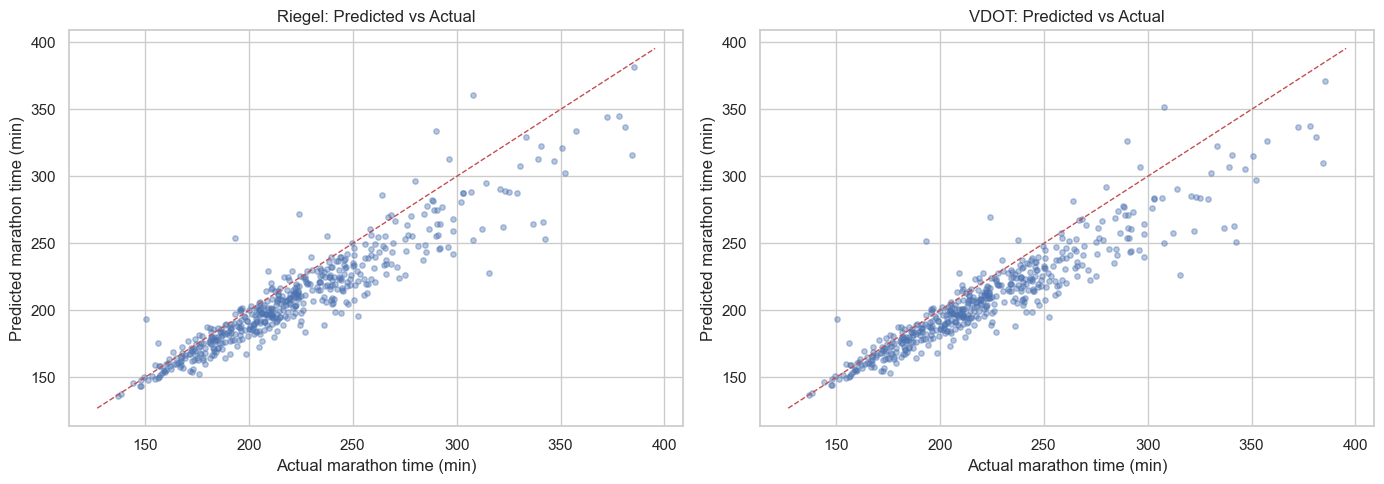

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name, col in zip(axes, ['Riegel', 'VDOT'], ['riegel_predicted', 'vdot_predicted']):
    ax.scatter(df['mf_ti_adj'], df[col], alpha=0.4, s=15)
    lims = [df['mf_ti_adj'].min() - 10, df['mf_ti_adj'].max() + 10]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Actual marathon time (min)')
    ax.set_ylabel('Predicted marathon time (min)')
    ax.set_title(f'{name}: Predicted vs Actual')
plt.tight_layout()
plt.savefig('../results/figures/baseline_predicted_vs_actual.png', dpi=150)

It looks like Riegel and VDOT systematically underpredict marathon times. These graphs are really interesting to me because of how tightly points hug under the line. It almost looks like these predictions act as a lower bound for marathon time, with exceptions increasing as marathoners become more elite. Since many marathoners are using these predictors, I'm thinking this phenomenon could occur because people see the prediction as their time to aim for. This could create a feedback loop where these predictors become self fullfilling. 

Those are ideas to dig into some other time though. What's relevant right now is that both of these predictors systematically underpredict times and that we have metrics for our model to beat.

Riegel:
  MAE  = 15.53 min
  RMSE = 20.89 min
  MAPE = 6.53%

VDOT:
  MAE  = 16.18 min
  RMSE = 21.70 min
  MAPE = 6.75%

These are beatable metrics. MAE of 15:32 minutes for Riegel means that a Riegel prediction could be off your actual pace by a significant amount, enough to totally blow up your pacing. RMSE of 20:53 minutes tells me that there are some runners for whom Riegel predictions were way off their actual time, and significantly more off than the average runner. This is easy to see on the graph. VDOT is slightly worse on all metrics. It's known in the marathon world that VDOT tends to underpredict more aggressively for longer distances than Riegel, so its cool to have actually discovered that on my own.

 MAPE of 6.53% is a good way to conceptualize the issue with these predictions. Nike spent many years and millions of dollars developing a $500 running shoe designed to improve marathon performance by 2%-3%. What's the point of something like that if your pace predictor sets you back more than twice as much?

### Goal Setting

I would be proud of my model got MAE under 10 minutes. I've read some research articles attempting to solve the same problem and they typically acheived 8-12 MAE. Another way to frame it is to aim for < 5% MAPE. I want to acheive these goals while keeping the model generalizeable.

---
## Part 1: Vickers Feature Engineering

Build new features from existing columns using domain knowledge. The goal is to extract information that raw columns don't capture directly.

### Imputed half-marathon

Longer distances will be best at predicting marathon time, so of course I want to use half marathon time as a feature. 106/493 runners are missing half-marathon times. As my dataset is small, and runners who haven't ran a half-marathon are a unique subset of my data I don't want to drop those rows. Instead I'm opting to impute times using Riegel, and put them in a new column. I will not impute times for the other races; I don't want to introduce so much redundant manufactured data into the dataset. It makes sense to do this for the most valuable race, but doing it for all races would just create noise. 

It needs to be noted that this will skew half marathon time faster, as we just saw that Riegel tends to underpredict times. We can inspect after to see how bad the skew is.

In [119]:
non_hf_races = [
    ('m10_ti_adj', 10),
    ('k10_ti_adj', 6.2),
    ('m5_ti_adj', 5),
    ('k5_ti_adj', 3.1),
]

df["imputed_mh_ti_adj"] = np.nan

for col, dist in non_hf_races:
    mask = df["mh_ti_adj"].isna() & df[col].notna()
    df.loc[mask, "imputed_mh_ti_adj"] = df.loc[mask, col].apply(
        lambda t: riegel_predict(race_time=t, race_distance=dist, target_distance=13.1)
    )

# merged imputed and actual vals
df["mh_ti_adj_final"] = df["mh_ti_adj"].fillna(df["imputed_mh_ti_adj"])

# actual vals
# still stored in df["mh_ti_adj"]

# imputed flag
df["mh_ti_adj_imputed_flag"] = df["mh_ti_adj"].isna() & df["imputed_mh_ti_adj"].notna()


Cool, but I want to see how the imputed data looks vs. Our regular half marathon data.

In [120]:
print(round((df["imputed_mh_ti_adj"].mean() - df["mh_ti_adj"].mean()) / df["mh_ti_adj"].mean(), 4))

-0.04


Hm. Imputed half marathons are 4% faster than our actual half marathons. This bugs me. There could be lots of reasons for this. For example, I know that Riegel underpredicts with an MAE of 6.53%. This could also be a faster subset of runners. Or it could be a slower subset of runners, and that's why they are slower than the Riegel underprediction would suggest. 

I could try and do a regression-based imputation, or MICE, but even though this shift is larger than I'd like it to be, it only shifts half-marathon 1% overall, and half marathon is only one feature in my dataset. Although I would like to try this new method and perhaps improve the quality of my dataset, its best for me to stay on track and keep making progress.

### Pace features

I'm adding pace for each runner. I'll use this to create other features.

In [121]:
races = [
    ('mh_ti_adj', 13.1),
    ('imputed_mh_ti_adj', 13.1),
    ('m10_ti_adj', 10),
    ('k10_ti_adj', 6.2),
    ('m5_ti_adj', 5),
    ('k5_ti_adj', 3.1),
]

for col, dist in races:
    df[f"pace_{col}"] = np.nan

for col, dist in races:
    mask = df[col].notna()
    df.loc[mask, f"pace_{col}"] = df.loc[mask, col].apply(
        lambda t: t / dist
    )


I'm curious what the pace distributions look like in our dataset. Lets take a look.

In [122]:
pace_cols = [
    'pace_mh_ti_adj',
    'pace_imputed_mh_ti_adj',
    'pace_m10_ti_adj',
    'pace_k10_ti_adj',
    'pace_m5_ti_adj',
    'pace_k5_ti_adj',
]

df[pace_cols].describe()

,pace_mh_ti_adj,pace_imputed_mh_ti_adj,pace_m10_ti_adj,pace_k10_ti_adj,pace_m5_ti_adj,pace_k5_ti_adj
count,387.000000,106.000000,66.000000,203.000000,45.000000,285.000000
mean,7.718713,7.410261,7.431592,7.356855,7.032726,6.844838
std,1.402185,1.448766,1.433230,1.420406,1.635530,1.234649
min,4.984619,5.014697,5.175000,4.977265,4.869992,4.599283
25%,6.765267,6.541291,6.405323,6.397234,5.863333,6.026882
50%,7.532628,7.083648,7.271988,7.092046,6.733333,6.591398
75%,8.402672,7.988561,7.911284,8.037791,7.653333,7.349462
max,13.201470,12.806004,11.621667,15.161290,13.191137,11.745163


Neat. It looks like our runners are faster on average than what I have experienced the average runner to be. This is worth keeping in mind in the future.

### Endurance ratio

One quirk of running is that the different metabolic aspects of running (power, lactate threshold, endurance, steady-state) is that they don't have 1:1 carry over to eachother when you train them. This is intuitive for most people; you wouldn't expect a 100m trackstar to be better at the marathon than a marathoner, and vice versa. Whats useful about this to us is measuring runner's speed (5k time) against their half marathon time. This gives trainers a picture of how developed different metabolic aspects of running are in a runner, and for our model it will be a useful feature.

In [123]:
cond_1 = df["k5_ti_adj"].notna() | df["m5_ti_adj"].notna()
cond_2 = df["m10_ti_adj"].notna() | df["mh_ti_adj"].notna()

def calc_endurance_ratio(row):
    # finds viable rows, returns pace
    if pd.notna(row["mh_ti_adj"]):
        long_pace = row["pace_mh_ti_adj"]
    else:
        long_pace = row["pace_m10_ti_adj"]
    if pd.notna(row["k5_ti_adj"]):
        short_pace = row["pace_k5_ti_adj"]
    else:
        short_pace = row["m5_ti_adj"]

    return long_pace / short_pace

df["endurance_ratio"] = df.apply(calc_endurance_ratio, axis=1)

df["endurance_ratio"].head(5)


6     1.048512
13    1.164594
21    1.128226
24    1.129602
25    1.165669
Name: endurance_ratio, dtype: float64

### Mean VDOT

Average of VDOT's each runner earned from their races.

In [124]:
races = [
    ('mh_ti_adj', 13.1),
    ('m10_ti_adj', 10),
    ('k10_ti_adj', 6.2),
    ('m5_ti_adj', 5),
    ('k5_ti_adj', 3.1),
]

df["mean_vdot"] = 0.0

for race, dist in races:
    mask = df[race].notna() 
    df.loc[mask, "mean_vdot"] += df.loc[mask, race].apply(
        lambda t: vdot_from_race(race_time=t, race_distance=dist) / 2
        )

### Consistency via VDOT comparison

Compare VDOT's from both races ran, create coefficient based off of consistency. Measure % difference between mean VDOT and absolute difference of runner's individual VDOT scores.

In [125]:
races = [
    ('mh_ti_adj', 13.1),
    ('m10_ti_adj', 10),
    ('k10_ti_adj', 6.2),
    ('m5_ti_adj', 5),
    ('k5_ti_adj', 3.1),
]

def calc_consistency(row):
    vdots = []

    for race, dist in races:
        if pd.notna(row[race]):
            vdots.append(vdot_from_race(race_time=row[race], race_distance=dist))

    return 1 - (abs(vdots[0] - vdots[1]) / row["mean_vdot"])


df["vdot_consistency"] = df.apply(calc_consistency, axis=1)

### Longest race submitted

The longest race submitted could be a useful proxy measure of runner maturity.

In [126]:
races = [
    ('mh_ti_adj', 13.1),
    ('m10_ti_adj', 10),
    ('k10_ti_adj', 6.2),
    ('m5_ti_adj', 5),
    ('k5_ti_adj', 3.1),
]

df["longest_race_dist"] = 0.0

for race, dist in races:
    mask = df[race].notna() & (df["longest_race_dist"] < dist)
    df.loc[mask, "longest_race_dist"] = dist

### Missing value strategy

I imputed half marathon times because its the most valuable predictor we have (based on EDA) and because we were only missing 22% of data in that column. That's a significant portion, but within what I deem acceptable. I don't want to drop any of my data, as we have few features in this dataset. To run a regression, I'll create a clone dataset with columns that have missing data dropped.

### Before/after comparison

How do the new features relate to marathon time? Which correlate most strongly?

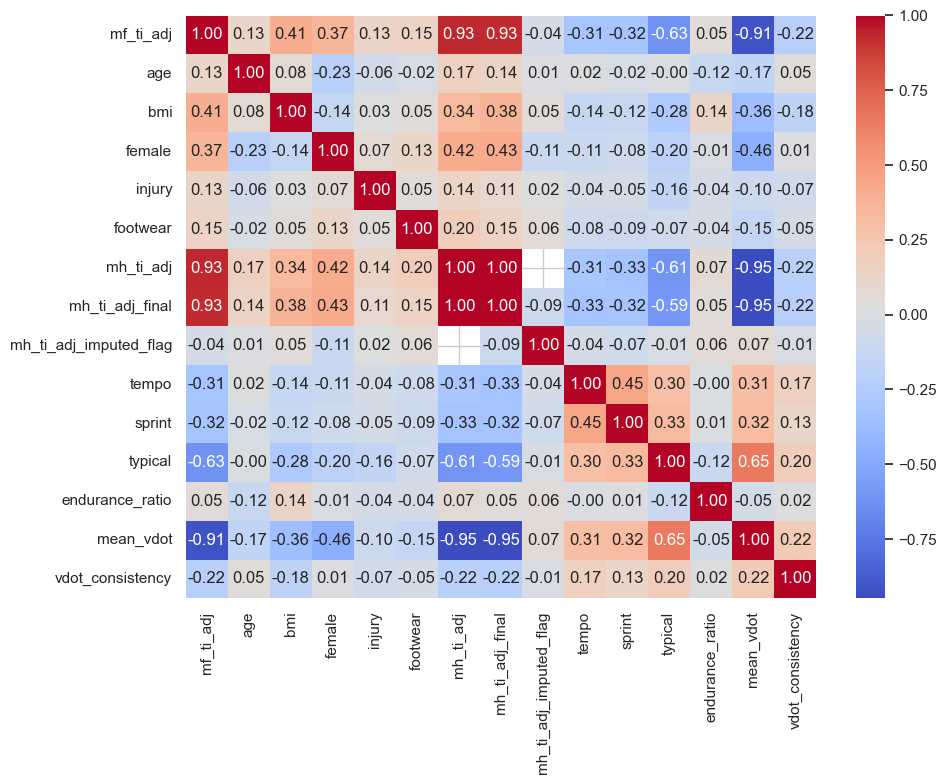

In [127]:
# Correlation of new features with marathon time
cols = [
    "mf_ti_adj",
    "age",
    "bmi",
    "female",
    "injury",
    "footwear",
    "mh_ti_adj",
    "mh_ti_adj_final",
    "mh_ti_adj_imputed_flag",
    "tempo",
    "sprint",
    "typical",
    "endurance_ratio",
    "mean_vdot",
    "vdot_consistency",
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.tight_layout()
plt.show()

Imputed half marathon and half marathon without imputed data are at 1. This makes total sense, but I should drop one. I'm going to opt for dropping the non-imputed data and keeping the flag. To go further, the imputed half marathon data has a -0.96 correlation with mean VDOT. I shouldn't keep both. What would be more interesting than dropping one would be to train a model with VDOT as the main predictor and another with imputed half marathon. Both of these choices leak influence from other marathon predictors into my dataset (Riegel in the imputed half, obvs VDOT in mean VDOT), but it would be interesting to see which performs better. I'm also going to drop endurance ratio as its barely correlated and has nan values.

The only other variable with strong multicollinearity is typical mileage with the half marathon times, and therefore also with mean VDOT. For each of those it hovers around |0.6|, but it still encodes lots of unique information in the model, and that level of multicollinearity isn't devastating, so I'm keeping it. Everything else is a keeper.

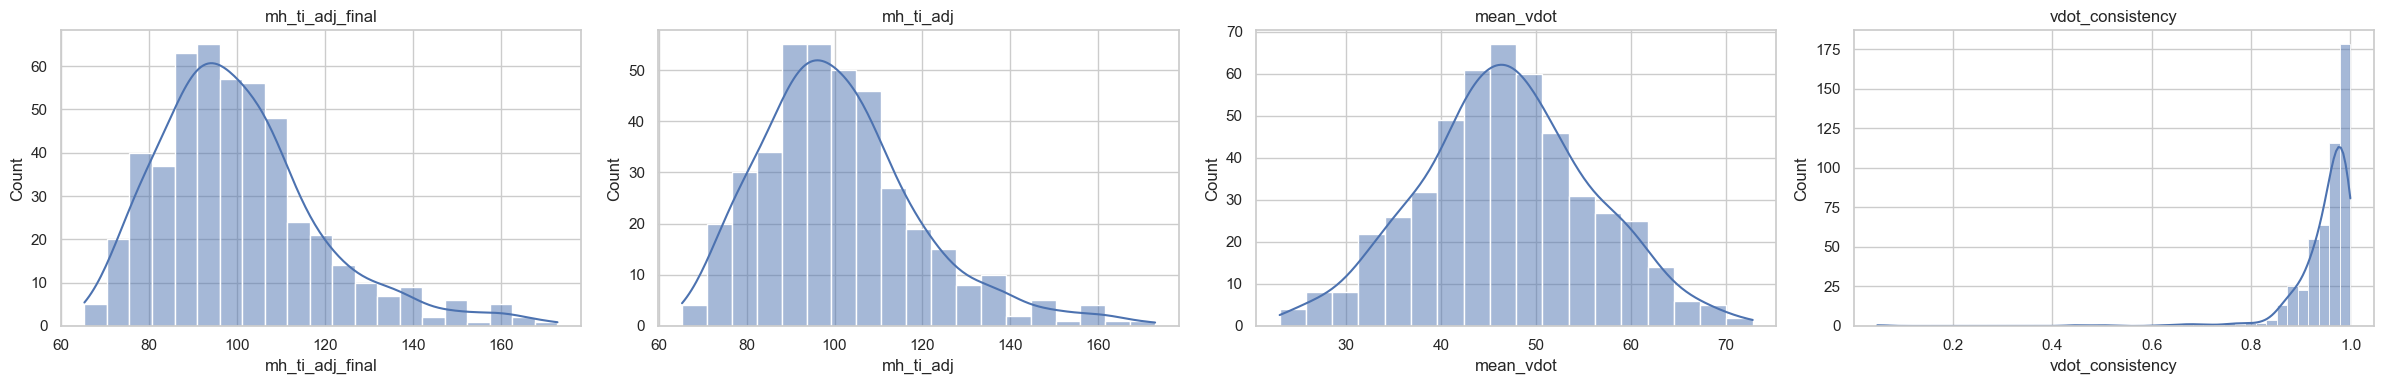

In [128]:
# Distribution plots of new features
features =  ["mh_ti_adj_final",
             "mh_ti_adj",
             "mean_vdot",
             "vdot_consistency",
    ]

fig, axes = plt.subplots(1, len(features), figsize=(6 * len(features), 4))

for ax, feat in zip(axes, features):
    sns.histplot(df[feat].dropna(), kde=True, ax=ax)
    ax.set_title(feat)

plt.tight_layout()
plt.show()

Imputed half and actual half data has almost the same shape, which is a good sign. Mean vdot is incredibly normally distributed. But woof. vdot_consistency has some truly insane values. Let's take a look at these outliers.

In [129]:
df.nsmallest(15, "vdot_consistency")[["mean_vdot", "vdot_consistency"] + [r for r, _ in races]]

,mean_vdot,vdot_consistency,mh_ti_adj,m10_ti_adj,k10_ti_adj,m5_ti_adj,k5_ti_adj
1356,35.420,0.048560,88.000000,NaN,94.000000,NaN,NaN
2017,45.695,0.447423,130.183333,NaN,NaN,28.833333,NaN
1954,56.935,0.500659,104.741170,NaN,NaN,24.349959,NaN
1912,40.385,0.626346,NaN,NaN,59.000000,NaN,20.620636
1279,34.040,0.667450,NaN,NaN,NaN,40.000000,32.045054
429,32.575,0.672448,116.000000,NaN,69.000000,NaN,NaN
612,42.100,0.696912,122.000000,NaN,NaN,NaN,20.418846
843,30.390,0.717670,125.083333,NaN,NaN,NaN,34.333130
1575,48.185,0.755733,NaN,79.150456,NaN,NaN,18.598187
1567,48.870,0.763863,103.957039,NaN,NaN,NaN,18.429757


Interesting. Some people are just truly inconsistent. The most inconsistent runner ran a half marathon at around 11 minute pace, but then a 5-miler under 5 minute pace. I can only imagine that that's a data entry issue. From a training perspective, its nigh impossible to between those two levels of fitness in a single training cycle, let alone a year. The 15th least consistent runner ran a half marathon at ~10 minute pace, but then a 10k at 7 minute pace. That is actually pretty reasonable over the course of a few months of serious training, so that data is probably valid (not miss input). 

The 9nth least consistent runner (75.57% consistency) with believeable times. Running a 10-miler a little under 8 minute pace, and then a 5k just under 6 minute pace is possible with great training over a good few months. 

Let's see how many of these runners classify as statistical outliers.

In [130]:
def print_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = series[(series < lower) | (series > upper)]
    print(f"IQR: {iqr:.2f}, Bounds: [{lower:.2f}, {upper:.2f}]")
    print(f"Outliers: {len(outliers)} / {len(series)} ({len(outliers)/len(series)*100:.1f}%)")
    print(outliers.describe())
    return outliers

print_outliers(df["vdot_consistency"])

IQR: 0.05, Bounds: [0.85, 1.06]
Outliers: 20 / 493 (4.1%)
count    20.000000
mean      0.705985
std       0.191755
min       0.048560
25%       0.671199
50%       0.767143
75%       0.824667
max       0.852632
Name: vdot_consistency, dtype: float64


66      0.770423
125     0.852632
393     0.796545
429     0.672448
612     0.696912
633     0.790698
725     0.833031
843     0.717670
1279    0.667450
1356    0.048560
1567    0.763863
1575    0.755733
1606    0.843767
1793    0.821878
1854    0.851599
1908    0.844135
1912    0.626346
1949    0.817936
1954    0.500659
2017    0.447423
Name: vdot_consistency, dtype: float64

Alright, all of the datapoints I think are impossible (8 least consistent) classify as statistical outliers. I'm going to drop them from the dataset because I think that data is corrupted. I won't drop the rest, even though they will introduce skew in a linear model; I'm going to end up using a tree based model because of all the nan data I have.

In [131]:
df = df.drop(df.nsmallest(8, "vdot_consistency").index)

### Save engineered features

In [132]:
df.to_parquet('../data/processed/vickers_features.parquet', index=False)

---
## Part 2: Train/Test Split

Prepare final feature matrix and target variable, then split for modeling.

In [133]:
df.columns

Index(['id', 'adjusted', 'age', 'bmi', 'cohort1', 'cohort2', 'cohort3',
       'cohort4', 'endurancecat', 'endurancespeed', 'female', 'footwear',
       'group', 'injury', 'k5_d', 'k5_di', 'k5_ti', 'k5_ti_adj', 'k5_tr',
       'k10_d', 'k10_di', 'k10_ti', 'k10_ti_adj', 'k10_tr', 'm5_d', 'm5_di',
       'm5_ti', 'm5_ti_adj', 'm5_tr', 'm10_d', 'm10_di', 'm10_ti',
       'm10_ti_adj', 'm10_tr', 'mh_d', 'mh_di', 'mh_ti', 'mh_ti_adj', 'mh_tr',
       'mf_d', 'mf_di', 'mf_ti', 'mf_ti_adj', 'mf_tr', 'max', 'sprint',
       'tempo', 'typical', 'model1_time', 'model2_time', 'other_races',
       'riegel_predicted', 'vdot_predicted', 'imputed_mh_ti_adj',
       'mh_ti_adj_final', 'mh_ti_adj_imputed_flag', 'pace_mh_ti_adj',
       'pace_imputed_mh_ti_adj', 'pace_m10_ti_adj', 'pace_k10_ti_adj',
       'pace_m5_ti_adj', 'pace_k5_ti_adj', 'endurance_ratio', 'mean_vdot',
       'vdot_consistency', 'longest_race_dist'],
      dtype='str')

### Define X and y

I'm choosing to exclude pace data, self-reported endurance categories, longest distance ran (garbage correlation), and all race data but the half marathon data. Everything else has significant predictive value. The half marathon data and mean vdot do have lots of multicollinearity.

In [134]:
X = df[[
    "age",
    "bmi",
    "female",
    "injury",
    "footwear",
    "mh_ti_adj_final",
    "mh_ti_adj_imputed_flag",
    "tempo",
    "sprint",
    "typical",
    "mean_vdot",
    "vdot_consistency",
]]

y = df["mf_ti_adj"]

### Split

I have enough data for a 80/20 split.

In [135]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows')

Train: 388 rows, Test: 97 rows


### Verify split distributions

Check that train and test sets have similar distributions.

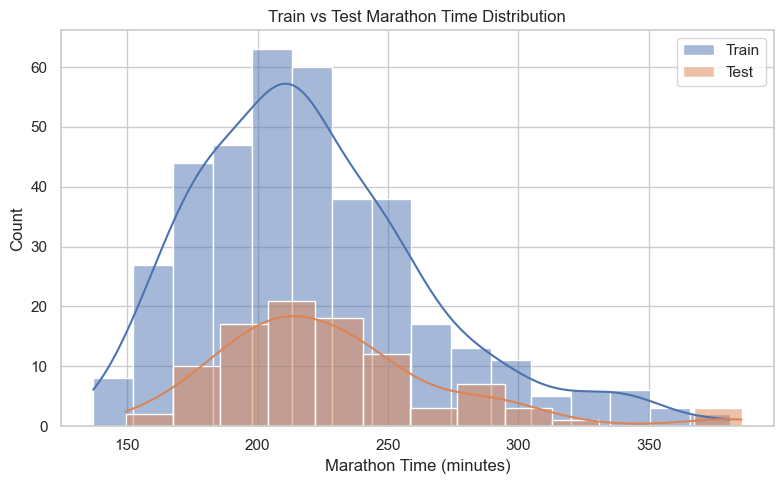

In [136]:
# Histogram overlay of train vs test marathon times

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(y_train, kde=True, label="Train", alpha=0.5, ax=ax)
sns.histplot(y_test, kde=True, label="Test", alpha=0.5, ax=ax)
ax.set_xlabel("Marathon Time (minutes)")
ax.set_title("Train vs Test Marathon Time Distribution")
ax.legend()
plt.tight_layout()
plt.show()

Looks good! Test set does have a slow outlier, but the kde is really similar overall so I'm not super worried. I think this is a good split to proceed with.

### Save

In [137]:
# Save train/test splits
train = pd.concat([X_train, y_train], axis=1)
test = pd.concat([X_test, y_test], axis=1)
train.to_parquet('../data/processed/train.parquet', index=False)
test.to_parquet('../data/processed/test.parquet', index=False)

---
## Feature engineering summary

Alright, feature engineering is all wrapped up. I'm decently happy with what we have. We have some decent features to work with here; those VDOT features are worth something, even though they are largely derivations of race data. Whats more important is that we now have all of our data properly sorted, fitted, and split. On to training!